# Customer Churn Project (Classification)

In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [29]:
df_telco = pd.read_csv('BasicML/telco_churn.csv')

In [30]:
# Encode catogorical variable
le = LabelEncoder()
df_telco['Churn'] = le.fit_transform(df_telco['Churn'])

In [31]:
# Define Features and Target here
X = df_telco.drop(columns=['Churn'])
y = df_telco['Churn']

In [32]:
# Convert categorical columns to numeric
X = pd.get_dummies(X, drop_first=True)

In [33]:
# Scale Feature
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [34]:
# Split dataset
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [35]:
log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [36]:
# Train KNN model
knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [37]:
# Evaluating the model
log_pred = log_model.predict(X_test)
knn_pred = knn_model.predict(X_test)


In [38]:
#classification table
print("Logistic model classification:", classification_report(y_test, log_pred))
print("knn-Model classificationL:", classification_report(y_test, knn_pred))

Logistic model classification:               precision    recall  f1-score   support

           0       0.80      0.95      0.87       449
           1       0.76      0.93      0.84       284
           2       0.69      0.34      0.45       156
           3       0.66      0.31      0.42       119
           4       0.00      0.00      0.00         1

    accuracy                           0.77      1009
   macro avg       0.58      0.51      0.52      1009
weighted avg       0.76      0.77      0.74      1009

knn-Model classificationL:               precision    recall  f1-score   support

           0       0.45      1.00      0.62       449
           1       0.77      0.04      0.07       284
           2       0.00      0.00      0.00       156
           3       0.00      0.00      0.00       119
           4       0.00      0.00      0.00         1

    accuracy                           0.45      1009
   macro avg       0.24      0.21      0.14      1009
weighted avg       

C:\Users\priya\OneDrive\Desktop\ML Sangrah\MLSangrah\mlenv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\priya\OneDrive\Desktop\ML Sangrah\MLSangrah\mlenv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\priya\OneDrive\Desktop\ML Sangrah\MLSangrah\mlenv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

In [39]:
# Confusion matrix for logistic regression
print(" Logistic Model Confusion Matrix\n",confusion_matrix(y_test, log_pred))
print("Knn ModelConfusion Matrix\n",confusion_matrix(y_test, knn_pred))

 Logistic Model Confusion Matrix
 [[425   0  24   0   0]
 [  0 265   0  19   0]
 [103   0  53   0   0]
 [  0  82   0  37   0]
 [  1   0   0   0   0]]
Knn ModelConfusion Matrix
 [[449   0   0   0   0]
 [274  10   0   0   0]
 [156   0   0   0   0]
 [116   3   0   0   0]
 [  1   0   0   0   0]]


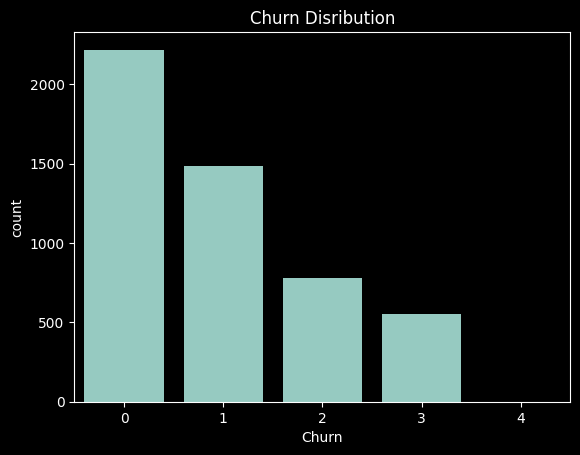

In [40]:
sns.countplot(x ='Churn', data=df_telco)
plt.title("Churn Disribution")
plt.show()